# RAG With Hatstack 2.0

**Author:** Shinin Varongchayakul

**Date:** 09 Jul 2026

Dataset from: https://www.kaggle.com/datasets/hgultekin/bbcnewsarchive

## 1. Indexing Pipeline

### 1.1 Create Documents

#### 1.1.1 Load the File

In [ ]:
# Import the package
import pandas as pd

# Load the CSV
df = pd.read_csv("bbc-news-data.csv", sep="\t")

In [ ]:
# Inspect the first 5 rows
df.head()

,category,filename,title,content
0,business,001.txt,Ad sales boost Time Warner profit,Quarterly profits at US media giant TimeWarne...
1,business,002.txt,Dollar gains on Greenspan speech,The dollar has hit its highest level against ...
2,business,003.txt,Yukos unit buyer faces loan claim,The owners of embattled Russian oil giant Yuk...
3,business,004.txt,High fuel prices hit BA's profits,British Airways has blamed high fuel prices f...
4,business,005.txt,Pernod takeover talk lifts Domecq,Shares in UK drinks and food firm Allied Dome...


#### 1.1.2 Convert to Document Objects

In [ ]:
# Import the package
from haystack import Document

# Instantiate a collector
docs = []

# Loop through the records
for row in df.itertuples():
    doc = Document(
        content=row.content,
        meta={
            "title": row.title,
            "category": row.category,
            "filename": row.filename
        }
    )
    docs.append(doc)

In [4]:
# Inspect one document
docs[0]

Document(id=7fe87ca8e57420adb9ed47866809d38424003dd43b4eefdf6b1a400eb3709677, content: ' Quarterly profits at US media giant TimeWarner jumped 76% to $1.13bn (£600m) for the three months t...', meta: {'title': 'Ad sales boost Time Warner profit', 'category': 'business', 'filename': '001.txt'})

### 1.2 Create a Splitter

In [ ]:
# Import the package
from haystack.components.preprocessors import RecursiveDocumentSplitter

# Create a splitter
splitter = RecursiveDocumentSplitter(
    split_length=180,
    split_overlap=30,
    split_unit="word",
    separators=[
        "\n\n",
        "sentence",
        "\n",
        " ",
    ]
)

### 1.3 Create an Embedder

In [ ]:
# Import the package
from haystack_integrations.components.embedders.sentence_transformers import (
    SentenceTransformersDocumentEmbedder
)

# Create a document embedder
document_embedder = SentenceTransformersDocumentEmbedder(
    model="sentence-transformers/all-MiniLM-L6-v2",
    meta_fields_to_embed=["title"],
)

### 1.4 Create a Vector Store

In [ ]:
# Import the package
from haystack.document_stores.in_memory import InMemoryDocumentStore

# Create a vector store
vector_store = InMemoryDocumentStore(
    embedding_similarity_function="cosine"
)

### 1.5 Create a Document Writer

In [ ]:
# Import the package
from haystack.components.writers import DocumentWriter

# Create a document writer
document_writer = DocumentWriter(
    document_store=vector_store
)

### 1.6 Create an Indexing Pipeline

In [ ]:
# Import the package
from haystack import Pipeline

# Instantiate a Pipeline object
indexing_pipeline = Pipeline()

In [ ]:
# Add the components
indexing_pipeline.add_component("splitter", splitter)
indexing_pipeline.add_component("embedder", document_embedder)
indexing_pipeline.add_component("writer", document_writer)

In [ ]:
# Connect the components
indexing_pipeline.connect("splitter.documents", "embedder.documents")
indexing_pipeline.connect("embedder.documents", "writer.documents")

🚅 Components
  - splitter: RecursiveDocumentSplitter
  - embedder: SentenceTransformersDocumentEmbedder
  - writer: DocumentWriter
🛤️ Connections
  - splitter.documents -> embedder.documents (list[Document])
  - embedder.documents -> writer.documents (list[Document])

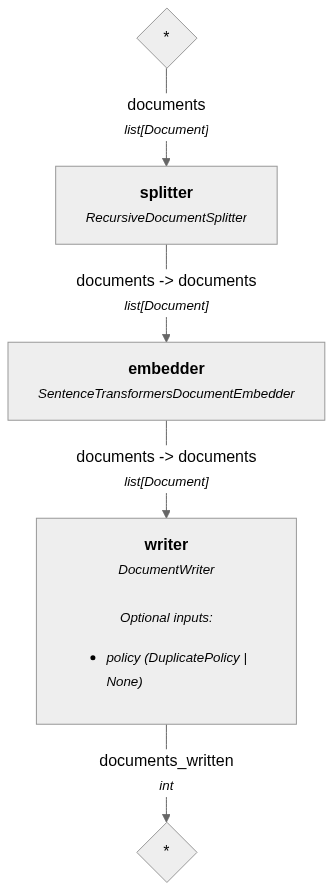

In [ ]:
# Display the pipeline
indexing_pipeline.show()

### 1.7 Run the Indexing Pipeline

In [13]:
# Run the indexing pipeline
indexing_result = indexing_pipeline.run(
    {
        "splitter": {
            "documents": docs
        }
    }
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/225 [00:00<?, ?it/s]

In [14]:
# Display the result
print(indexing_result)

{'writer': {'documents_written': 7182}}


## 2. Querying Pipeline

### 2.1 Create a Query Embedder

In [55]:
# Import the package
from haystack_integrations.components.embedders.sentence_transformers import (
    SentenceTransformersTextEmbedder
)

# Create a question embedder
question_embedder = SentenceTransformersTextEmbedder(
    model="sentence-transformers/all-MiniLM-L6-v2"
)

### 2.2 Create Retriever

In [56]:
# Import the package
from haystack.components.retrievers.in_memory import InMemoryEmbeddingRetriever

# Create a retriever
retriever = InMemoryEmbeddingRetriever(
    document_store=vector_store,
    top_k=5
)

### 2.3 Create Prompt Builder

In [57]:
# Set the system prompt
system_prompt = """
You are a helpful assistant for a historical BBC News Archive.

Answer only from the retrieved BBC article passages.

Rules:
- Be concise.
- Do not use outside knowledge.
- Do not invent facts that are not supported by the passages.
- The archive is historical, so do not present its content as current news.
- Cite factual claims using source labels such as [1] or [2].
- If the retrieved passages do not contain enough evidence, say that clearly.
- Response in short bullet points.
- At the end of the answer, include a "Sources:" section listing only the sources that were actually cited in the answer. Format each source as:
  - [n] <Title>
"""

# Set the user prompt
user_prompt = """
Question:
{{ question }}

Retrieved BBC archive passages:

{% for doc in docs %}
[{{ loop.index }}]

Title: {{ doc.meta["title"] }}
Category: {{ doc.meta["category"] }}
Filename: {{ doc.meta["filename"] }}

Passage:
{{ doc.content }}

{% endfor %}

Write a concise answer using only the retrieved passages.

After the answer, include:

Sources:
{% raw %}- [n] <Title>{% endraw %}

where each title corresponds to the cited passage, and list only the sources that were actually cited in the answer.
"""

In [58]:
# Import the packages
from haystack.components.builders import ChatPromptBuilder
from haystack.dataclasses import ChatMessage

# Create a prompt builder
prompt_builder = ChatPromptBuilder(
    template=[
        ChatMessage.from_system(system_prompt.strip()),
        ChatMessage.from_user(user_prompt.strip())
    ],
    required_variables=["question", "docs"],
)

### 2.4 Create a Response Generator

In [59]:
# Import the packages
import os
from pathlib import Path
from dotenv import load_dotenv

# Get the current working directory
CURRENT_DIR = Path.cwd()

# Move up to the project root
ROOT_DIR = CURRENT_DIR.parents[1]

# Define the path to .env
ENV_PATH = ROOT_DIR / ".env"

# Load the .env content
load_dotenv(dotenv_path=ENV_PATH)

# Get the API key
GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")

In [60]:
# Import the packages
from haystack.utils import Secret
from haystack_integrations.components.generators.google_genai import (
    GoogleGenAIChatGenerator
)

# Create a generator
generator = GoogleGenAIChatGenerator(
    model="gemini-2.5-flash",
    api_key=Secret.from_token(GEMINI_API_KEY),
    generation_kwargs={
        "temperature": 0.2
    }
)

### 2.5 Create a Querying Pipeline

In [ ]:
# Import the package
from haystack import Pipeline

# Instantiate a Pipeline object
querying_pipeline = Pipeline()

In [62]:
# Add the components
querying_pipeline.add_component("question_embedder", question_embedder)
querying_pipeline.add_component("retriever", retriever)
querying_pipeline.add_component("prompt_builder", prompt_builder)
querying_pipeline.add_component("generator", generator)

In [63]:
# Connect the components
querying_pipeline.connect("question_embedder.embedding", "retriever.query_embedding")
querying_pipeline.connect("retriever.documents", "prompt_builder.docs")
querying_pipeline.connect("prompt_builder.prompt", "generator.messages")

🚅 Components
  - question_embedder: SentenceTransformersTextEmbedder
  - retriever: InMemoryEmbeddingRetriever
  - prompt_builder: ChatPromptBuilder
  - generator: GoogleGenAIChatGenerator
🛤️ Connections
  - question_embedder.embedding -> retriever.query_embedding (list[float])
  - retriever.documents -> prompt_builder.docs (list[Document])
  - prompt_builder.prompt -> generator.messages (list[ChatMessage])

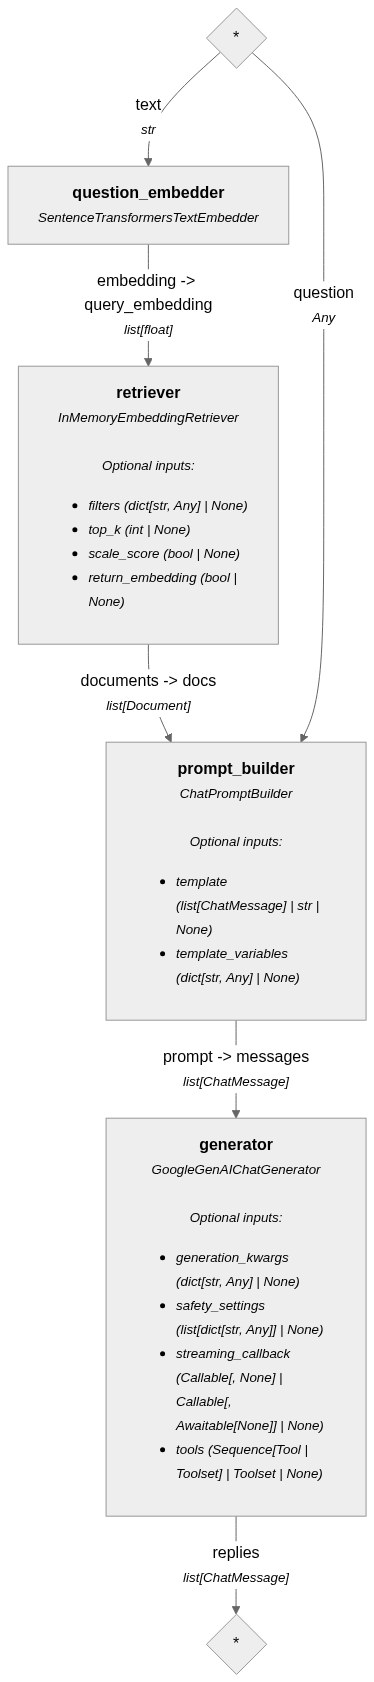

In [64]:
# Display the pipeline
querying_pipeline.show()

### 2.6 Run the Querying Pipeline

In [65]:
# Create the function to store the pipeline
def run_query(query: str):

    # Run pipeline
    result = querying_pipeline.run(
        {
            "question_embedder": {
                "text": query
            },
            "prompt_builder": {
                "question": query
            }
        }
    )

    # Return result
    return result["generator"]["replies"][0].text

In [66]:
# Set the question
my_question = "What concerns did users raise about Google’s AutoLink feature?"

# Run the query
query_result = run_query(query=my_question)

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

In [67]:
# Display the result
print(query_result)

Users raised several concerns about Google’s AutoLink feature:

*   It directs people to pre-selected commercial websites [1].
*   Google's dominant market position could give a competitive edge to firms like Amazon [1].
*   It creates links based on webpage information without the publisher's permission [1].
*   Online libraries and other websites might direct users to commercial sites like Amazon or rival services against their will or in conflict with their own advertising [4].
*   Some users felt it would only be fair if websites had to opt-in or receive revenue for "click throughs" to commercial sites [2].
*   Concerns were raised about user choice, transparency regarding Google's payments, and the ability to substitute preferred companies for those chosen by Google [3].
*   There was an objection to users being forced or tricked into using the service [3].
*   The feature was compared to Microsoft's Smart Tags, which was widely criticised [2].

Sources:
- [1] Google's toolbar spa